# step 1 - IMPORT THE CAT_VS_DOG DATASET

In [85]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#load the cat and dog dataset
from datasets import load_dataset
ds = load_dataset("microsoft/cats_vs_dogs", split="train")
print(ds)

Dataset({
    features: ['image', 'labels'],
    num_rows: 23410
})


In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


 # SPLIT DATA ....FOR THE TRAIN AND TEST DATA

In [4]:
ds = ds.train_test_split(test_size=0.2, seed=42)

train_ds = ds["train"]
test_ds = ds["test"]

print("Train:", len(train_ds))
print("Test:", len(test_ds))

Train: 18728
Test: 4682


In [5]:
print(train_ds[0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=320x240 at 0x18FCECB8850>, 'labels': 0}


In [6]:
print(train_ds.features["labels"]) # it tell the values of name what first and second

ClassLabel(names=['cat', 'dog'])


In [7]:
for i in range(10):
    print(i, train_ds[i]["labels"])

0 0
1 1
2 0
3 1
4 0
5 0
6 1
7 0
8 1
9 1


In [8]:
for i in range(10):
    print(i,test_ds[i]["labels"])

0 1
1 0
2 0
3 1
4 0
5 1
6 1
7 0
8 1
9 0


# Step 2 — See the actual images

In [9]:
sample=train_ds[0]
print(sample)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=320x240 at 0x18FCECBB790>, 'labels': 0}


In [10]:
image = sample["image"] # ["image"] its key word to see the image key values ....used to see the actual image
label = sample["labels"]

print("Image type:", type(image))
print("Label:", label)

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Label: 0


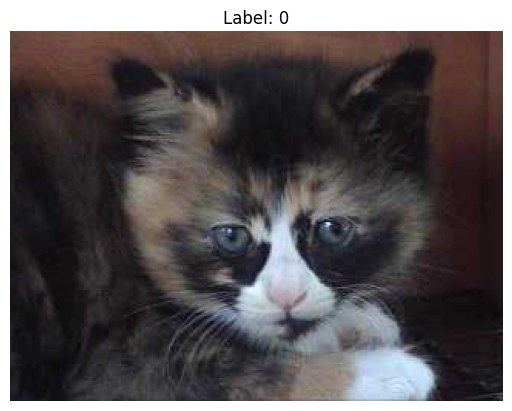

In [11]:

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [12]:
import matplotlib.pyplot as plt
import importlib

importlib.reload(plt)

<module 'matplotlib.pyplot' from 'C:\\Users\\gobinath\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\matplotlib\\pyplot.py'>

<class 'PIL.JpegImagePlugin.JpegImageFile'>
1


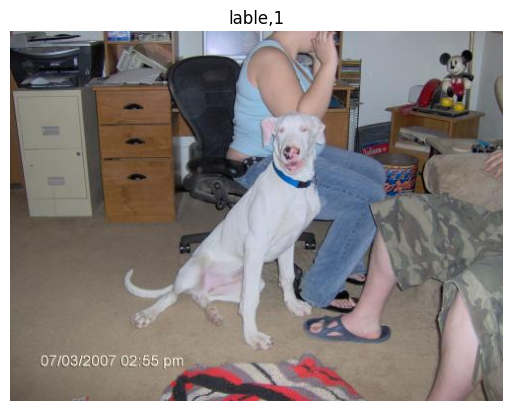

In [13]:
sample1=train_ds[1]
image=sample1["image"]
label=sample1["labels"]

print(type(image))
print(label)
plt.imshow(image)
plt.title(f"lable,{label}")
plt.axis("off")
plt.show()

<class 'PIL.JpegImagePlugin.JpegImageFile'>
1


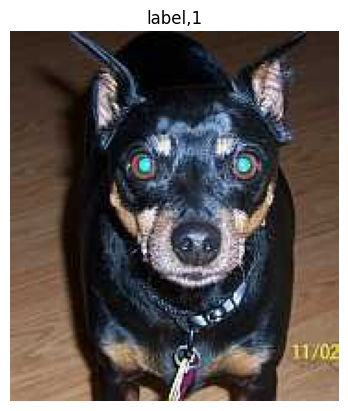

In [14]:
sample2=train_ds[3]
image=sample2["image"]
label=sample2["labels"]

print(type(image))
print(label)

plt.imshow(image)
plt.title(f"label,{label}")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(319.5), np.float64(239.5), np.float64(-0.5))

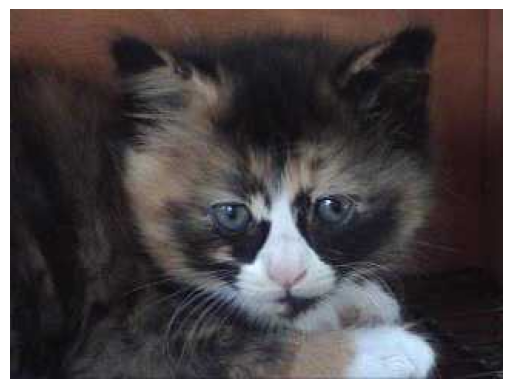

In [15]:
plt.imshow(train_ds[0]["image"])# use this line to seee the image
plt.axis("off")

# step-3 Understand the image

In [16]:
sample=train_ds[0]

image=sample["image"]
label=sample["labels"]

print(image.size)
print(image.mode)
print(label)

(320, 240)
RGB
0


In [17]:
np_array=np.array(image)

print(np_array.shape)
print(np_array.min())
print(np_array.max())

(240, 320, 3)
0
255


# step-4 change the All image size

In [42]:
def preprocess(example):
    image=example["image"]
    image = example["image"].convert("RGB").resize((128, 128))
    image=np.array(image,dtype=np.float32)
    image=image/255.0
    return{
        "image":image,
        "label":example["labels"]
    }



In [19]:
train_processed = train_ds.map(preprocess)

Map:   0%|          | 0/18728 [00:00<?, ? examples/s]

ArrowInvalid: arrays to be concatenated must be identically typed, but list<item: list<item: float>> and list<item: float> were encountered.

In [20]:
test_processed = test_ds.map(preprocess)

Map:   0%|          | 0/4682 [00:00<?, ? examples/s]

ArrowInvalid: arrays to be concatenated must be identically typed, but list<item: list<item: float>> and list<item: float> were encountered.

In [23]:
x["image"]

array([[[0.3764706 , 0.27450982, 0.22352941],
        [0.4       , 0.29411766, 0.24705882],
        [0.40392157, 0.2901961 , 0.24705882],
        ...,
        [0.40784314, 0.2509804 , 0.24313726],
        [0.38039216, 0.25490198, 0.23529412],
        [0.35686275, 0.25490198, 0.22745098]],

       [[0.38431373, 0.28235295, 0.23137255],
        [0.38039216, 0.2784314 , 0.22745098],
        [0.4       , 0.28235295, 0.23921569],
        ...,
        [0.40784314, 0.2509804 , 0.24313726],
        [0.38039216, 0.25490198, 0.23529412],
        [0.35686275, 0.25490198, 0.22745098]],

       [[0.3882353 , 0.28627452, 0.23529412],
        [0.37254903, 0.26666668, 0.21960784],
        [0.3882353 , 0.27058825, 0.22745098],
        ...,
        [0.40784314, 0.2509804 , 0.24313726],
        [0.38039216, 0.25490198, 0.23529412],
        [0.35686275, 0.25490198, 0.22745098]],

       ...,

       [[0.11764706, 0.10980392, 0.14509805],
        [0.10588235, 0.10196079, 0.13725491],
        [0.07058824, 0

In [38]:
print(type(x))
print(x.keys())

<class 'dict'>
dict_keys(['image', 'label'])


In [90]:
x = preprocess(train_ds[0])

print("Shape:", x["image"].shape)
print("Min:", x["image"].min())
print("Max:", x["image"].max())
print("Label:", x["labels"])

Shape: (128, 128, 3)
Min: 0.039215688
Max: 1.0


KeyError: 'labels'

# step 5 - CONVERT THE DATASET PROPER TO TRAINABLE DATA....AND DIVIDE THE BATCH WISE

In [44]:
def generator(dataset):
    for example in dataset:
        image = example["image"].convert("RGB").resize((128, 128))
        image = np.array(image, dtype=np.float32) / 255.0
        label = example["labels"]

        yield image, label

In [45]:
train_dataset = tf.data.Dataset.from_generator(  # train_dataset the vaiable store the all image ...resize and change the all
    lambda: generator(train_ds),
    output_signature=(
        tf.TensorSpec((128, 128, 3), tf.float32), # this line like reshape  the input shape
        tf.TensorSpec((), tf.int64)
    )
)

train_dataset = train_dataset.batch(32)

In [46]:
for images, labels in train_dataset.take(1): # take is ...take the one whole batch
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Images: (32, 128, 128, 3)
Labels: (32,)


# Build the CNN

In [36]:
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),
    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])



    

In [37]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
history = model.fit(
    train_dataset,
    epochs=5
)

Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 313s 533ms/step - accuracy: 0.6797 - loss: 0.5946
Epoch 2/5


C:\Users\gobinath\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


586/586 ━━━━━━━━━━━━━━━━━━━━ 320s 546ms/step - accuracy: 0.7629 - loss: 0.4869
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 1053s 2s/step - accuracy: 0.8213 - loss: 0.3936
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 287s 489ms/step - accuracy: 0.8796 - loss: 0.2790
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 305s 459ms/step - accuracy: 0.9172 - loss: 0.2005


# step 6 -Now we prepare the test dataset to testing

In [48]:
test_dataset = tf.data.Dataset.from_generator(
    lambda: generator(test_ds),
    output_signature=(
        tf.TensorSpec((128, 128, 3), tf.float32),
        tf.TensorSpec((), tf.int64)
    )
)

test_dataset = test_dataset.batch(32)

In [49]:
for image,lable in test_dataset.take(1):
    print(image.shape)
    print(labels.shape)

(32, 128, 128, 3)
(32,)


# step 7- Evaluate the model

In [50]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

147/147 ━━━━━━━━━━━━━━━━━━━━ 54s 363ms/step - accuracy: 0.7550 - loss: 0.7825
Test Accuracy: 0.7550192475318909
Test Loss: 0.7825024724006653


C:\Users\gobinath\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [51]:
sample = test_ds[0]

image = sample["image"]
label = sample["labels"]

print("Actual label:", label)

Actual label: 1


In [52]:
prediction = model.predict(
    np.expand_dims(
        np.array(image.convert("RGB").resize((128,128)), dtype=np.float32) / 255.0,
        axis=0
    )
)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
[[0.9998998]]


In [91]:
prediction = model.predict(
    np.expand_dims(x["image"], axis=0)
)

if prediction[0][0] >= 0.5:
    print("Dog")
else:
    print("Cat")

print(prediction.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Cat
(1, 1)


In [55]:
print("Actual:", x["label"])

Actual: 0


# step 7 - Improve the accuracy and reduce the overfitting

In [57]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [59]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [60]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [61]:
history = model.fit(
    train_dataset,
    epochs=5
)

Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 322s 540ms/step - accuracy: 0.5905 - loss: 0.6771
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 336s 573ms/step - accuracy: 0.6645 - loss: 0.6183
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 336s 572ms/step - accuracy: 0.7009 - loss: 0.5763
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 296s 504ms/step - accuracy: 0.7221 - loss: 0.5439
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 331s 563ms/step - accuracy: 0.7439 - loss: 0.5168


In [62]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

147/147 ━━━━━━━━━━━━━━━━━━━━ 51s 339ms/step - accuracy: 0.7589 - loss: 0.4950
Test Accuracy: 0.7588637471199036
Test Loss: 0.4950011074542999


# step 8- reduce the overfitting dropout the some values

In [63]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),                     # it reome some dataset values

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [64]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [65]:
history = model.fit(
    train_dataset,
    epochs=5
)

Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 363s 576ms/step - accuracy: 0.6289 - loss: 0.6571
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 679s 1s/step - accuracy: 0.7010 - loss: 0.5788
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 306s 521ms/step - accuracy: 0.7309 - loss: 0.5415
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 355s 577ms/step - accuracy: 0.7473 - loss: 0.5146
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 391s 593ms/step - accuracy: 0.7599 - loss: 0.4951


In [66]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

147/147 ━━━━━━━━━━━━━━━━━━━━ 55s 373ms/step - accuracy: 0.7907 - loss: 0.4545
Test Accuracy: 0.7906877398490906
Test Loss: 0.4544709622859955


In [67]:
sample = test_ds[10]

image = sample["image"]
actual = sample["labels"]

print("Actual:", actual)

Actual: 0


In [68]:
prediction = model.predict(
    np.expand_dims(
        np.array(image.convert("RGB").resize((128, 128)), dtype=np.float32) / 255.0,
        axis=0
    )
)

if prediction[0][0] >= 0.5:
    print("Predicted: Dog")
else:
    print("Predicted: Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
Predicted: Cat


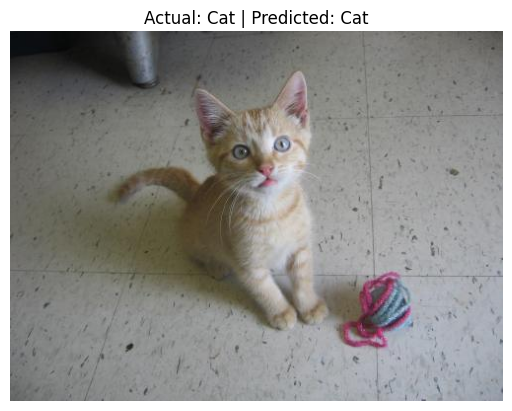

In [69]:

plt.imshow(image)
plt.title("Actual: Cat | Predicted: Cat")
plt.axis("off")
plt.show()

In [70]:
for i in range(10):
    sample = test_ds[i]

    image = sample["image"]
    actual = sample["labels"]

    x = np.array(
        image.convert("RGB").resize((128, 128)),
        dtype=np.float32
    ) / 255.0

    prediction = model.predict(
        np.expand_dims(x, axis=0),# this place go one by one ....use expand to write 1 
        verbose=0
    )

    if prediction[0][0] >= 0.5:
        predicted = 1
    else:
        predicted = 0

    print("Image:", i, "| Actual:", actual, "| Predicted:", predicted)

Image: 0 | Actual: 1 | Predicted: 1
Image: 1 | Actual: 0 | Predicted: 0
Image: 2 | Actual: 0 | Predicted: 0
Image: 3 | Actual: 1 | Predicted: 1
Image: 4 | Actual: 0 | Predicted: 0
Image: 5 | Actual: 1 | Predicted: 0
Image: 6 | Actual: 1 | Predicted: 1
Image: 7 | Actual: 0 | Predicted: 0
Image: 8 | Actual: 1 | Predicted: 0
Image: 9 | Actual: 0 | Predicted: 0


# TWO WRONG PREDICTIONS

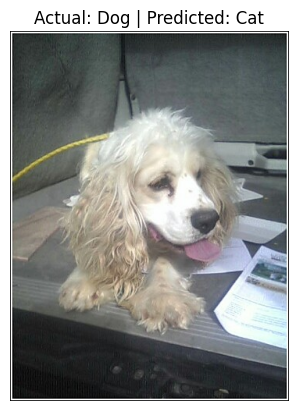

In [71]:
sample = test_ds[5]

image = sample["image"]

plt.imshow(image)
plt.title("Actual: Dog | Predicted: Cat")
plt.axis("off")
plt.show()

In [74]:
sample = test_ds[5]

x = np.array(
    sample["image"].convert("RGB").resize((128, 128)),
    dtype=np.float32
) / 255.0

prediction = model.predict(
    np.expand_dims(x, axis=0),
    verbose=0
)

print("Dog probability:", prediction[0][0])

Dog probability: 0.40561786


In [73]:
sample = test_ds[8]

x = np.array(
    sample["image"].convert("RGB").resize((128, 128)),
    dtype=np.float32
) / 255.0

prediction = model.predict(
    np.expand_dims(x, axis=0),
    verbose=0
)

print("Dog probability:", prediction[0][0])

Dog probability: 0.40723276


# test the model

In [75]:
from PIL import Image

image = Image.open("new_dog.jpg")

print("Size:", image.size)
print("Mode:", image.mode)
plt.im

Size: (1200, 800)
Mode: RGB


In [76]:
x = np.array(
    image.resize((128, 128)),
    dtype=np.float32
) / 255.0

print(x.shape)
print(x.min(), x.max())

(128, 128, 3)
0.003921569 1.0


In [77]:
prediction = model.predict(
    np.expand_dims(x, axis=0),
    verbose=0
)

print("Dog probability:", prediction[0][0])

Dog probability: 0.9935634


# MODEL SAVE AND LOAD THE MODELS

In [79]:
model.save("cat_dog_model.keras")

In [80]:
import os

print(os.path.exists("cat_dog_model.keras"))

True


In [81]:
loaded_model = tf.keras.models.load_model("cat_dog_model.keras")

In [82]:
print(loaded_model)

<Sequential name=sequential_6, built=True>


In [83]:
prediction = loaded_model.predict(
    np.expand_dims(x, axis=0),
    verbose=0
)

print("Dog probability:", prediction[0][0])

Dog probability: 0.9935634


In [84]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = loaded_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend((predictions >= 0.5).astype(int).flatten())

print("Actual:", len(y_true))
print("Predicted:", len(y_pred))

Actual: 4682
Predicted: 4682


# TELL HOW WRONG PREDICTION

In [86]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[1833  502]
 [ 478 1869]]


In [87]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))


              precision    recall  f1-score   support

         Cat       0.79      0.79      0.79      2335
         Dog       0.79      0.80      0.79      2347

    accuracy                           0.79      4682
   macro avg       0.79      0.79      0.79      4682
weighted avg       0.79      0.79      0.79      4682



In [88]:
from PIL import Image
import numpy as np

img = Image.open("new_dog.jpg").convert("RGB")

img = img.resize((128, 128))

img = np.array(img, dtype=np.float32) / 255.0

img = np.expand_dims(img, axis=0)

prediction = loaded_model.predict(img, verbose=0)[0][0]

if prediction >= 0.5:
    print("Predicted: Dog")
    print("Dog probability:", prediction)
else:
    print("Predicted: Cat")
    print("Cat probability:", 1 - prediction)

Predicted: Dog
Dog probability: 0.9935634
